# Task 4 — Modality Gap in CLIP



In [1]:
!pip install -q git+https://github.com/openai/CLIP.git umap-learn scikit-learn scipy

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.4 MB/s eta 0:00:00


In [2]:
# Imports and device
import torch, numpy as np, matplotlib.pyplot as plt
import clip
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import accuracy_score
import umap
from scipy.linalg import orthogonal_procrustes
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device =', device)

device = cuda


In [3]:
# Load CLIP model
model, preprocess = clip.load('ViT-B/32', device=device)
model.eval()
print('Loaded CLIP model')

100%|███████████████████████████████████████| 338M/338M [00:10<00:00, 33.7MiB/s]


Loaded CLIP model


In [4]:
# STL-10 test set
transform = preprocess
stl_test = datasets.STL10(root='./data', split='test', download=True, transform=transform)
test_loader = DataLoader(stl_test, batch_size=64, shuffle=False, num_workers=2)
# STL-10 class names
stl_labels = ['airplane','bird','car','cat','deer','dog','horse','monkey','ship','truck']
print('Number of test images:', len(stl_test))

100%|██████████| 2.64G/2.64G [01:02<00:00, 42.6MB/s]


Number of test images: 8000


In [ ]:
# Prompting 
prompt_templates = {
    'plain': ['{}'],
    'a_photo_of': ['a photo of a {}','a picture of a {}','a photograph of a {}'],
    'descriptive': ['a close-up of a {} in the wild','a {} in its environment','a detailed photo of a {}']
}
def build_text_embeddings(model, labels, templates):
    texts = []
    for lab in labels:
        for t in templates:
            texts.append(t.format(lab))
    tokenized = clip.tokenize(texts).to(device)
    with torch.no_grad():
        text_feats = model.encode_text(tokenized).float()

    text_feats = text_feats.cpu().numpy()
    C = len(labels)
    k = len(templates)
    text_avg = text_feats.reshape(C, k, -1).mean(axis=1)

    text_avg = text_avg / np.linalg.norm(text_avg, axis=1, keepdims=True)
    return text_avg

text_embeddings = {k: build_text_embeddings(model, stl_labels, v) for k,v in prompt_templates.items()}

In [6]:
# Compute image embeddings
all_image_feats = []
all_labels = []
for imgs, targets in tqdm(test_loader):
    imgs = imgs.to(device)
    with torch.no_grad():
        feats = model.encode_image(imgs).float()
    feats = feats.cpu().numpy()
    feats = feats / np.linalg.norm(feats, axis=1, keepdims=True)
    all_image_feats.append(feats)
    all_labels.append(targets.numpy())
all_image_feats = np.vstack(all_image_feats)
all_labels = np.concatenate(all_labels)
print('Image feats shape:', all_image_feats.shape)

100%|██████████| 125/125 [00:20<00:00,  6.17it/s]

Image feats shape: (8000, 512)


In [7]:
# Zero-shot
def zero_shot_accuracy(image_feats, text_feats):
    sims = image_feats.dot(text_feats.T)
    preds = sims.argmax(axis=1)
    return accuracy_score(all_labels, preds)
results = {}
for name, t_emb in text_embeddings.items():
    results[name] = zero_shot_accuracy(all_image_feats, t_emb)
results
print('Zero-shot accuracies:')
for k,v in results.items(): print(k, v)

Zero-shot accuracies:
plain 0.9625
a_photo_of 0.973625
descriptive 0.97275


In [ ]:
# embedding visualization
N = 100
idx = np.random.choice(len(all_labels), size=N, replace=False)
img_subset = all_image_feats[idx]
labels_subset = all_labels[idx]
text_ref = text_embeddings['a_photo_of'][labels_subset]
print('Subset shapes', img_subset.shape, text_ref.shape)

Subset shapes (100, 512) (100, 512)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


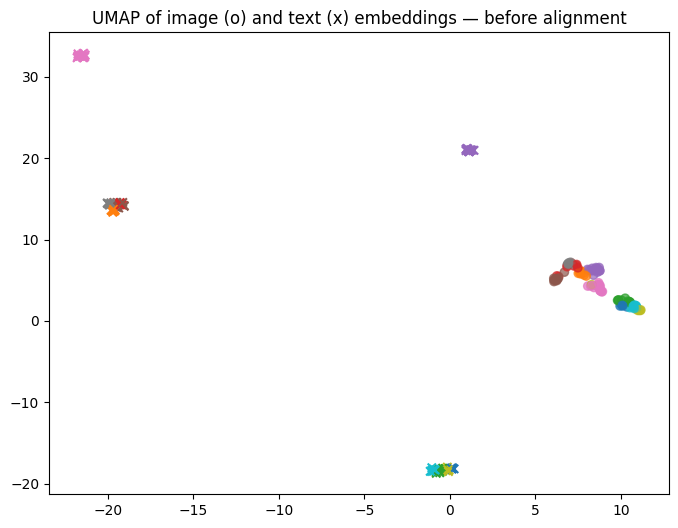

In [ ]:
# Visualize modalities with UMAP 
reducer = umap.UMAP(n_components=2, random_state=42)
combined = np.vstack([img_subset, text_ref])
proj = reducer.fit_transform(combined)
img_proj = proj[:len(img_subset)]
text_proj = proj[len(img_subset):]
plt.figure(figsize=(8,6))
plt.scatter(img_proj[:,0], img_proj[:,1], c=labels_subset, cmap='tab10', marker='o', alpha=0.7, label='image')
plt.scatter(text_proj[:,0], text_proj[:,1], c=labels_subset, cmap='tab10', marker='x', alpha=1.0, label='text')
plt.title('UMAP of image (o) and text (x) embeddings — before alignment')
plt.show()

Got rotation matrix R shape (512, 512) scale 87.17202


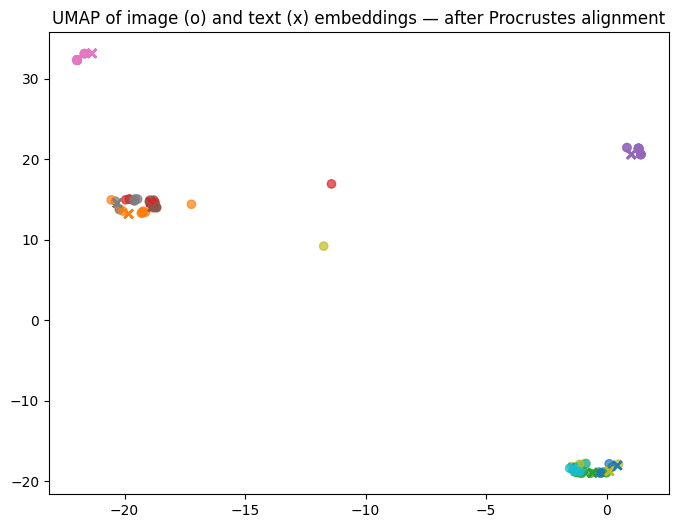

In [ ]:
R, scale = orthogonal_procrustes(img_subset, text_ref)
print('Got rotation matrix R shape', R.shape, 'scale', scale)
img_aligned = img_subset.dot(R) * scale

combined2 = np.vstack([img_aligned, text_ref])
proj2 = reducer.transform(combined2) if hasattr(reducer, 'transform') else reducer.fit_transform(combined2)
img_proj2 = proj2[:len(img_aligned)]
text_proj2 = proj2[len(img_aligned):]
plt.figure(figsize=(8,6))
plt.scatter(img_proj2[:,0], img_proj2[:,1], c=labels_subset, cmap='tab10', marker='o', alpha=0.7)
plt.scatter(text_proj2[:,0], text_proj2[:,1], c=labels_subset, cmap='tab10', marker='x', alpha=1.0)
plt.title('UMAP of image (o) and text (x) embeddings — after Procrustes alignment')
plt.show()

In [ ]:
all_image_aligned = all_image_feats.dot(R) * scale
text_for_eval = text_embeddings['a_photo_of']
acc_before = results['a_photo_of']
from sklearn.metrics import accuracy_score
preds_before = all_image_feats.dot(text_for_eval.T).argmax(axis=1)
preds_after = all_image_aligned.dot(text_for_eval.T).argmax(axis=1)
acc_after = accuracy_score(all_labels, preds_after)
print(f'Accuracy before alignment (a_photo_of): {acc_before:.4f}')
print(f'Accuracy after alignment: {acc_after:.4f}')

Accuracy before alignment (a_photo_of): 0.9736
Accuracy after alignment: 0.9711
